## Importation des bibliotheques

In [1]:
import os
import cv2
import numpy as np
from PIL import Image
import pickle
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [2]:
from ultralytics import YOLO
model_yolo = YOLO(r"/mnt/dtamboudisk/SYSTEME DE RECON-FACIAL/reco_facial-ai/yolov10n.pt")

## Montons le drive et verifions le dataset

In [ ]:

dataset_path = r"/mnt/dtamboudisk/SYSTEME DE RECON-FACIAL/reco_facial-ai/dataset"

personnes = os.listdir(dataset_path)
print(f"le dataset contient: {len (personnes)} personnes")

le dataset contient: 26 personnes


## verification du dataset

In [ ]:
toutes_images = []
tous_labels = []

for personne in sorted(os.listdir(dataset_path)):
    personne_path = os.path.join(dataset_path, personne)
    for image_file in os.listdir(personne_path):
        toutes_images.append(os.path.join(personne_path, image_file))
        tous_labels.append(personne)

images_entrainement_paths, images_test_paths, labels_entrainement, labels_test = train_test_split(
    toutes_images, tous_labels,
    test_size=0.2,
    random_state=50,
    stratify=tous_labels
)

print(f"Entrainement : {len(images_entrainement_paths)} images")
print(f"Test : {len(images_test_paths)} images")

Entrainement : 2040 images
Test : 510 images


## Separation du dataset en donnees d'entrainement et donnees test

In [ ]:
toutes_images = []
tous_labels = []

for personne in sorted(os.listdir(dataset_path)):
    personne_path = os.path.join(dataset_path, personne)
    for img_file in os.listdir(personne_path):
        toutes_images.append(os.path.join(personne_path, img_file))
        tous_labels.append(personne)

images_train_paths, images_test_paths, labels_train, labels_test = train_test_split(
    toutes_images, tous_labels,
    test_size=0.2,
    random_state=50,
    stratify=tous_labels
)
print(f"Train : {len(images_train_paths)} images — Test : {len(images_test_paths)} images")

Train : 2040 images — Test : 510 images


## Pretaitement des images ou des donnees

In [ ]:
def pretraitement_image(image_path, image_size=(160, 160)):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)
    image = np.array(image).astype(np.float32)
    image = (image - 127.5) / 128.0
    return image

def chargement_donnees(chemins, labels):
    images = []
    labels_out = []
    for chemin, label in zip(chemins, labels):
        try:
            image = pretraitement_image(chemin)
            images.append(image)
            labels_out.append(label)
        except Exception as e:
            print(f"erreur lors du chargement de l'image {chemin}: {e}")
    return np.array(images), labels_out

print("donnees d'entrainement")
images_entrainement, label_entrainement = chargement_donnees(
    images_entrainement_paths, labels_entrainement)

print("donnees test")
images_test, label_test = chargement_donnees(
    images_test_paths, labels_test)

print(f"entrainement: {images_entrainement.shape} et labels : {len(label_entrainement)}")
print(f"test: {images_test.shape} et labels: {len(label_test)}")

donnees d'entrainement
donnees test
entrainement: (2040, 160, 160, 3) et labels : 2040
test: (510, 160, 160, 3) et labels: 510


## Visualisation

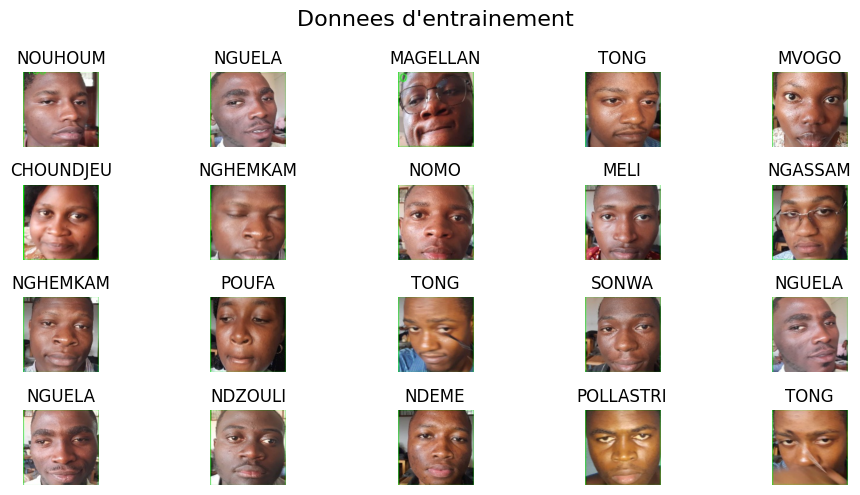

In [ ]:
def denormalisation(image):
    return (image * 128.0 + 127.5).astype(np.uint8)

figure, axes = plt.subplots(4, 5, figsize=(10, 5))

for i, graphique in enumerate(axes.flat):
    graphique.imshow(denormalisation(images_entrainement[i*100]))
    graphique.set_title(label_entrainement[i*100])
    graphique.axis("off")

plt.suptitle("Donnees d'entrainement", fontsize=16)
plt.tight_layout()
plt.show()

## FaceNet: installation et chargement

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
from keras_facenet import FaceNet


facenet = FaceNet()
print("FaceNet charger avec succes!!!")


I0000 00:00:1780667226.039341  351960 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780667228.228468  351960 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


FaceNet charger avec succes!!!


##

## Extraction des embeddings

In [ ]:
def extraction_embeddings(images, taille_paquet=30):
  embeddings = []

  for i in range(0, len(images), taille_paquet):
    paquet_images = images[i:i+taille_paquet]
    paquet_uint8 = (paquet_images*128.0+127.5).astype(np.uint8)
    paquet_embeddings = facenet.embeddings(paquet_uint8)
    embeddings.extend(paquet_embeddings)

    print(f"paquet{i//taille_paquet+1}/{len(images)//taille_paquet+1}", end="\r")

  return np.vstack(embeddings)

print("extraction d'embeddings pour les donnees d'entrainement: ")
embeddings_entrainement = extraction_embeddings(images_entrainement)

print("extraction d'embeddings pour les donnees test:")
embeddings_test = extraction_embeddings(images_test)

print(f"embeddings entrainement: {embeddings_entrainement.shape}")
print(f"embeddings test: {embeddings_test.shape}")

extraction d'embeddings pour les donnees d'entrainement: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 

Encodage des labels et SVM

In [ ]:
# Encodage des labels
le = LabelEncoder()
y_train = le.fit_transform(label_entrainement)
y_test = le.transform(label_test)

print(f"Classes reconnues : {list(le.classes_)}")

# Entraînement du classificateur SVM
classificateur = SVC(kernel='rbf', probability=True, C=1.0)
classificateur.fit(embeddings_entrainement, y_train)

print("Classificateur entraîné ✓")

Classes reconnues : [np.str_('BOUETOU'), np.str_('CHOUNDJEU'), np.str_('FOGUE'), np.str_('IYA'), np.str_('KAMDEM'), np.str_('KAMWA'), np.str_('MAFFO'), np.str_('MAGELLAN'), np.str_('MATCHOO'), np.str_('MELI'), np.str_('MVOGO'), np.str_('NDEME'), np.str_('NDZOULI'), np.str_('NGASSAM'), np.str_('NGHEMKAM'), np.str_('NGUELA'), np.str_('NOMO'), np.str_('NOUHOUM'), np.str_('POLLASTRI'), np.str_('POUFA'), np.str_('RICKY'), np.str_('SONWA'), np.str_('TANGA'), np.str_('TETKA'), np.str_('TONG'), np.str_('TOUNGSI')]
Classificateur entraîné ✓


Évaluation du modèle

Accuracy : 98.82%

              precision    recall  f1-score   support

     BOUETOU       1.00      0.95      0.97        20
   CHOUNDJEU       1.00      1.00      1.00        20
       FOGUE       1.00      1.00      1.00        20
         IYA       1.00      1.00      1.00        20
      KAMDEM       1.00      1.00      1.00        20
       KAMWA       1.00      1.00      1.00        20
       MAFFO       0.95      1.00      0.98        20
    MAGELLAN       0.83      1.00      0.91        20
     MATCHOO       1.00      1.00      1.00        20
        MELI       1.00      1.00      1.00        20
       MVOGO       1.00      0.95      0.97        20
       NDEME       1.00      0.95      0.97        20
     NDZOULI       1.00      0.95      0.97        20
     NGASSAM       1.00      0.95      0.97        20
    NGHEMKAM       1.00      1.00      1.00        20
      NGUELA       1.00      1.00      1.00        20
        NOMO       1.00      1.00      1.00        20
     NOU

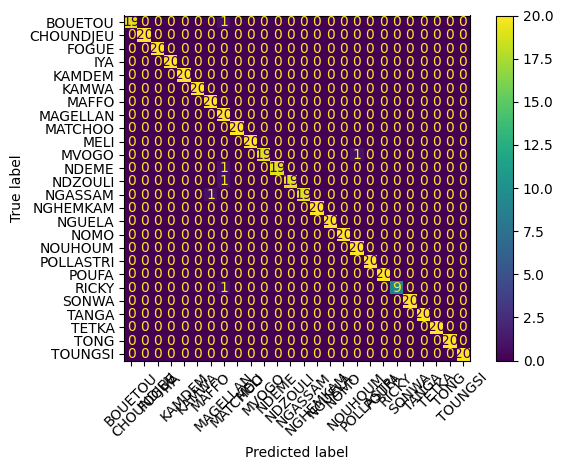

In [ ]:
y_pred = classificateur.predict(embeddings_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.tight_layout()
plt.show()

Sauvegarde

In [ ]:
# Sauvegarde du classificateur
dossier_sauvegarde = r"C:\Users\HP PC\Desktop\reco_facial-ai"
with open(os.path.join(dossier_sauvegarde, "classificateur.pkl"), "wb") as f:
    pickle.dump(classificateur, f)

# Sauvegarde de l'encodeur de labels
with open(os.path.join(dossier_sauvegarde, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

# sauvegarde des embeddings

np.save(os.path.join(dossier_sauvegarde, "embeddings_entrainement.npy"), embeddings_entrainement)
np.save(os.path.join(dossier_sauvegarde, "embeddings_test.npy"), embeddings_test)

print("classificateur.pkl sauvegardé ")
print("label_encoder.pkl sauvegardé ")
print("embeddings_entrainement.npy sauvegardé")
print("embeddings_test.npy sauvegardé")

classificateur.pkl sauvegardé 
label_encoder.pkl sauvegardé 
embeddings_entrainement.npy sauvegardé
embeddings_test.npy sauvegardé


## Reconnaissance en temps reel

In [ ]:
# =========================
# CHARGEMENT DES MODELES
# =========================

folder = r"/mnt/dtamboudisk/SYSTEME DE RECON-FACIAL/reco_facial-ai"

clf_path = os.path.join(folder, "classificateur.pkl")
le_path = os.path.join(folder, "label_encoder.pkl")
yolo_path = os.path.join(folder, "yolov10n-face.pt")

assert os.path.exists(clf_path), f"{clf_path} introuvable"
assert os.path.exists(le_path), f"{le_path} introuvable"
assert os.path.exists(yolo_path), f"{yolo_path} introuvable"

with open(clf_path, "rb") as f:
    classificateur = pickle.load(f)

with open(le_path, "rb") as f:
    le = pickle.load(f)

modele_yolo = YOLO(yolo_path)

seuil_de_confiance = 0.70

# Ne traiter qu'une image sur 5
frame_index = 0
frame_skip = 5


# =========================
# RECONNAISSANCE FACIALE
# =========================

def identification_visage(visage_traiter):

    visage_rgb = cv2.cvtColor(
        visage_traiter,
        cv2.COLOR_BGR2RGB
    )

    visage_redimensionne = np.array(
        Image.fromarray(visage_rgb).resize((160, 160))
    ).astype(np.uint8)

    embedding = facenet.embeddings(
        np.expand_dims(visage_redimensionne, axis=0)
    )

    prediction = classificateur.predict_proba(embedding)[0]

    index = np.argmax(prediction)

    confiance = prediction[index]

    if confiance >= seuil_de_confiance:

        nom = le.classes_[index]

        return (
            f"Bienvenue {nom} ({confiance:.2f})",
            (0, 255, 0)
        )

    return (
        f"Inconnu ({confiance:.2f})",
        (0, 0, 255)
    )


# =========================
# WEBCAM
# =========================

capture = cv2.VideoCapture(0)

if not capture.isOpened():
    raise Exception("Impossible d'ouvrir la webcam")

print("Demarrer - Appuyez sur Q pour quitter")

while True:

    retourne, image_capturee = capture.read()

    if not retourne:
        break

    frame_index += 1

    # Skip de frames pour accélérer
    if frame_index % frame_skip != 0:

        cv2.imshow(
            "SYSTEME DE RECONNAISSANCE FACIALE POUR BIOMETRIE INTELLIGENTE",
            image_capturee
        )

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

        continue

    # Détection visage YOLO
    resultats = modele_yolo(
        image_capturee,
        verbose=False
    )[0]

    for boite in resultats.boxes:

        confiance_detection = float(boite.conf[0])

        if confiance_detection < 0.50:
            continue

        x1, y1, x2, y2 = map(
            int,
            boite.xyxy[0]
        )

        x1 = max(0, x1)
        y1 = max(0, y1)

        x2 = min(image_capturee.shape[1], x2)
        y2 = min(image_capturee.shape[0], y2)

        extrait_visage = image_capturee[
            y1:y2,
            x1:x2
        ]

        if extrait_visage.size == 0:
            continue

        try:

            message, couleur = identification_visage(
                extrait_visage
            )

            cv2.rectangle(
                image_capturee,
                (x1, y1),
                (x2, y2),
                couleur,
                2
            )

            cv2.putText(
                image_capturee,
                message,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                couleur,
                2
            )

        except Exception as e:
            print("Erreur :", e)

    cv2.imshow(
        "SYSTEME DE RECONNAISSANCE FACIALE POUR BIOMETRIE INTELLIGENTE",
        image_capturee
    )

    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("VOUS AVEZ ARRETER LA CAPTURE")
        break


capture.release()
cv2.destroyAllWindows()

/home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Demarrer - Appuyez sur Q pour quitter


QFontDatabase: Cannot find font directory /home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/td2f/recon-facial-py311/venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━

In [1]:
print("facenet" in globals())

False
